In [1]:
import numpy as np
from matplotlib import pyplot as plt

import sklearn
import urllib.request

In [164]:
from astroML.datasets import generate_mu_z
from sklearn.gaussian_process import GaussianProcessRegressor, kernels
from scipy.optimize import fmin_cobyla
from sklearn.gaussian_process.kernels import ConstantKernel, RBF

In [157]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_predict


from astroML.linear_model import NadarayaWatson

(35.0, 50.0)

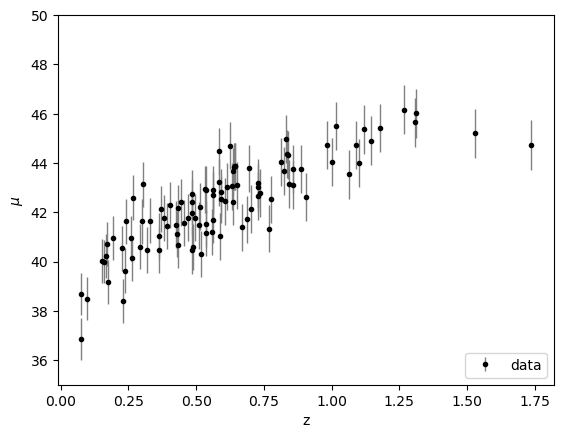

In [168]:
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) ###YOU CAN'T CHANGE THIS

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.ylim(35,50)

In [169]:
X = z_sample[:, np.newaxis]
y = mu_sample
dy = dmu

In [170]:
from sklearn.gaussian_process import GaussianProcessRegressor


gp = GaussianProcessRegressor()
gp.fit(X,y)
y_pred, dy_pred = gp.predict(X, return_std=True)
print(y_pred, dy_pred)

[41.07638168 42.77434921 41.89893723 43.54593658 43.52067566 41.3233223
 41.33478165 43.62639618 45.97229385 44.16949844 41.59358978 42.17916489
 43.07579041 43.21356964 41.63742828 42.46971893 42.18893814 38.52647781
 43.48760986 44.25140381 41.61836243 42.74076462 40.36556625 41.63234329
 45.2681694  42.91981888 41.73702621 43.56199265 41.45797729 42.50397491
 44.09506989 41.89244843 43.62780762 40.88618469 43.17429352 43.17577744
 41.16379929 45.04374123 41.91745758 44.68630981 40.14256668 41.05136871
 39.90218735 43.03451157 42.63656998 42.33295822 39.80730057 42.47089767
 41.49913025 42.1883812  40.7024231  42.69962692 42.49328613 37.77714157
 42.75102615 44.74455643 43.57055283 44.7473011  45.98566437 43.57749176
 41.36096954 42.78836441 42.07417679 41.09030151 41.68124008 40.03666306
 41.95787811 45.18601608 40.78002167 40.75201416 43.33189774 42.59989548
 42.04525757 40.66818619 41.19535065 44.51096344 41.81330109 42.34530258
 37.69273376 41.40759277 41.89543915 42.72447968 44.

In [171]:
kernels.RBF?

Init signature: kernels.RBF(length_scale=1.0, length_scale_bounds=(1e-05, 100000.0))
Docstring:     
Radial basis function kernel (aka squared-exponential kernel).

The RBF kernel is a stationary kernel. It is also known as the
"squared exponential" kernel. It is parameterized by a length scale
parameter :math:`l>0`, which can either be a scalar (isotropic variant
of the kernel) or a vector with the same number of dimensions as the inputs
X (anisotropic variant of the kernel). The kernel is given by:

.. math::
    k(x_i, x_j) = \exp\left(- \frac{d(x_i, x_j)^2}{2l^2} \right)

where :math:`l` is the length scale of the kernel and
:math:`d(\cdot,\cdot)` is the Euclidean distance.
For advice on how to set the length scale parameter, see e.g. [1]_.

This kernel is infinitely differentiable, which implies that GPs with this
kernel as covariance function have mean square derivatives of all orders,
and are thus very smooth.
See [2]_, Chapter 4, Section 4.2, for further details of the RBF kern

In [172]:
GaussianProcessRegressor?

Init signature:
GaussianProcessRegressor(
    kernel=None,
    *,
    alpha=1e-10,
    optimizer='fmin_l_bfgs_b',
    n_restarts_optimizer=0,
    normalize_y=False,
    copy_X_train=True,
    n_targets=None,
    random_state=None,
)
Docstring:     
Gaussian process regression (GPR).

The implementation is based on Algorithm 2.1 of [RW2006]_.

In addition to standard scikit-learn estimator API,
:class:`GaussianProcessRegressor`:

* allows prediction without prior fitting (based on the GP prior)
* provides an additional method `sample_y(X)`, which evaluates samples
  drawn from the GPR (prior or posterior) at given inputs
* exposes a method `log_marginal_likelihood(theta)`, which can be used
  externally for other ways of selecting hyperparameters, e.g., via
  Markov chain Monte Carlo.

To learn the difference between a point-estimate approach vs. a more
Bayesian modelling approach, refer to the example entitled
:ref:`sphx_glr_auto_examples_gaussian_process_plot_compare_gpr_krr.py`.

Rea

In [173]:
#w/o picking a specific kernel
gp3 = GaussianProcessRegressor()
gp3.fit(X,y)
linx = np.linspace(min(z_sample),max(z_sample),1000)[:, np.newaxis]
y_pred, dy_pred = gp3.predict(X, return_std=True)
y_predx, dy_predx = gp3.predict(linx, return_std=True)

In [182]:
# Constrain the mean and covariance with many noisy points

dy3 = dy
length_scale = 0.5

kernel3 = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(10, (1e-2, 1e2))
gp3 = GaussianProcessRegressor(kernel=kernel3,
                               alpha=dy3**2,
                               random_state=0)
gp3.fit(X,y)
linx = np.linspace(min(z_sample),max(z_sample),1000)[:, np.newaxis]
y_pred, dy_pred = gp3.predict(X, return_std=True)
y_predx, dy_predx = gp3.predict(linx, return_std=True)

(35.0, 50.0)

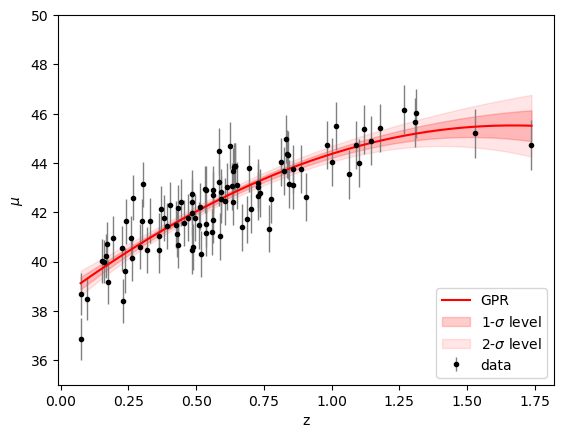

In [181]:
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
#plt.errorbar(z_sample, y_pred, dy_pred, fmt='.r', ecolor='gray', lw=1,label='GPR')
plt.plot(linx, y_predx, color='r', label='GPR')
plt.fill_between(linx[:,0], y_predx - dy_predx, y_predx + dy_predx, color='r', alpha=0.2, label='1-$\sigma$ level')
plt.fill_between(linx[:,0], y_predx - 2*dy_predx, y_predx + 2*dy_predx, color='r', alpha=0.1, label='2-$\sigma$ level')

plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.ylim(35,50)

(35.0, 50.0)

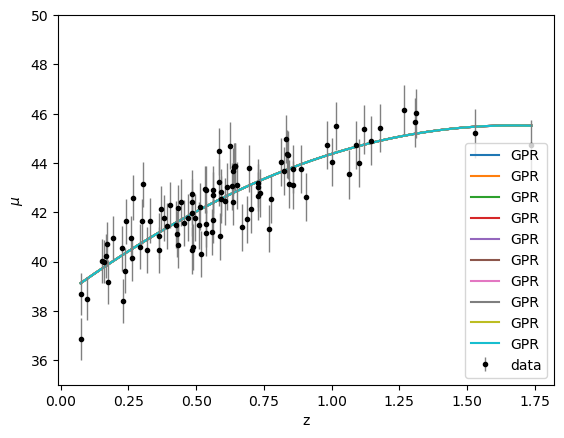

In [195]:
# Constrain the mean and covariance with many noisy points

dy3 = dy
lscales = np.logspace(-3,3,10)
for ls in lscales:

    kernel3 = ConstantKernel(1.0, (1e-3, 1e3))*kernels.RBF(ls, (0.01, 100.0))
    gp3 = GaussianProcessRegressor(kernel=kernel3,
                                   alpha=dy3**2,
                                   random_state=0)
    gp3.fit(X,y)
    linx = np.linspace(min(z_sample),max(z_sample),10000)[:, np.newaxis]
    y_predx, dy_predx = gp3.predict(linx, return_std=True)
    
    
    plt.plot(linx, y_predx, label='GPR')

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')

plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.ylim(35,50)